In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import matplotlib.gridspec as gridspec
from scipy import stats
from scipy.stats import skew
import statsmodels.api as sm

import customclass as cc


In [2]:
# PLOT STYLING OPTIONS
plt.style.use('seaborn-v0_8-bright')

textcolor = "#2a2a2a"
gridcolor = "#d6d6d6"

plt.rcParams.update({
    'figure.figsize': (9, 8),
    'lines.linewidth': 4,
    'lines.linestyle': "-", 
    'text.color': textcolor,
    'axes.labelcolor': textcolor,
    'axes.edgecolor': textcolor,
    'xtick.color': textcolor,
    'ytick.color': textcolor,
    'axes.titlecolor': textcolor,
    'font.family': 'serif',
    'font.serif': 'Times New Roman',
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'axes.titlesize': 24,
    'axes.labelsize': 20,
    'xtick.labelsize': 17,
    'ytick.labelsize': 17,
    'legend.fontsize': 19,
    'xtick.major.size': 11,
    'ytick.major.size': 11
})

boxprops = dict(boxstyle='round', facecolor='lightgrey', alpha=0.4)

colors = ["tab:blue", "tab:green", "tab:orange", "tab:purple", "tab:red", "tab:grey"]
cmaps = ["Blues", "Greens", "Oranges", "Purples", "Reds", "Greys"]

pf_sizes = np.arange(2, 32 + 1, 3) # portfolio sizes 
pf_horizons = np.arange(1, 25 + 1, 3) # investment horizons


In [3]:
# SYSTEM SPECIFICATIONS

import platform
import psutil
import cpuinfo # the package is called 'py-cpuinfo'

print("\n### System Specifications ###")
print("System:", platform.system())
print("Architecture:", cpuinfo.get_cpu_info()["arch"])
print("CPU:", cpuinfo.get_cpu_info()["brand_raw"])
print("CPU Cores:", psutil.cpu_count(logical=True)) 
print("Memory:", round(psutil.virtual_memory().total / (1024 ** 3), 2), "Gigabytes")
print("Python", platform.python_version())


### System Specifications ###
System: Windows
Architecture: X86_64
CPU: AMD Ryzen 7 7800X3D 8-Core Processor
CPU Cores: 16
Memory: 31.12 Gigabytes
Python 3.12.4


# Summary Statistics and Data Visualization

In [4]:
# LOAD DATA
ret_df = pd.read_csv("./DATA/ret_full.csv", header=0, index_col=0) * 100
all_returns = ret_df.values.flatten()
all_returns = all_returns[~np.isnan(all_returns)] 

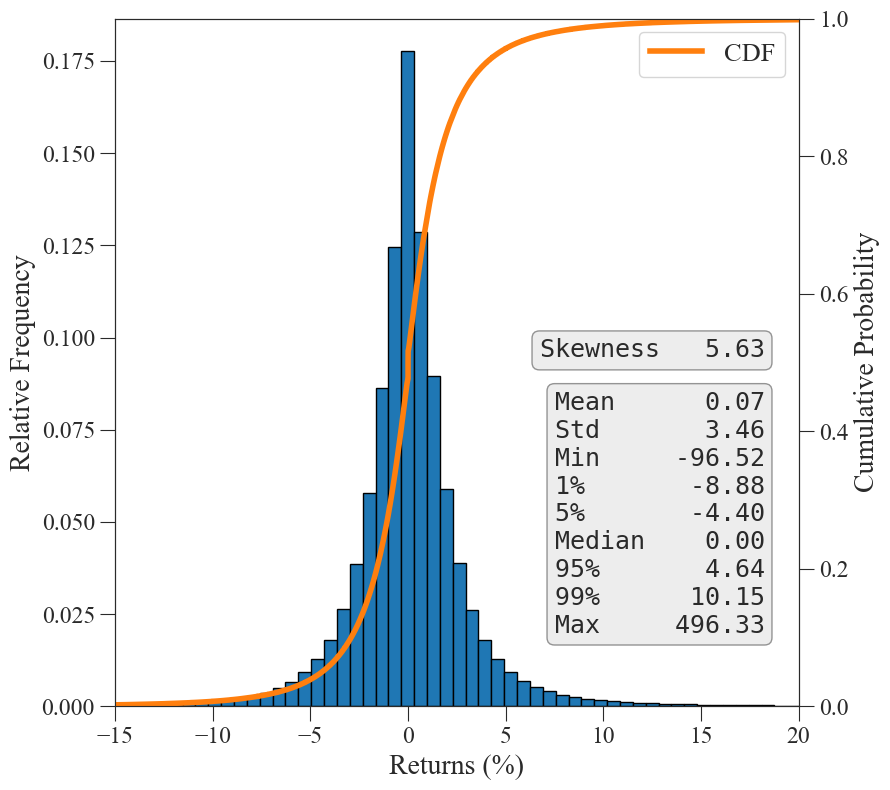

In [6]:
# DATA VISUALIZATION 1

fig, ax = plt.subplots()

ax.hist(all_returns, bins=900, color=colors[0], edgecolor='black', weights=np.ones(len(all_returns)) / len(all_returns))

# create secondary y-axis for CDF
ax2 = ax.twinx()

# calculate and plot CDF
sorted_returns = np.sort(all_returns)
cdf = np.arange(1, len(sorted_returns) + 1) / len(sorted_returns)
ax2.plot(sorted_returns, cdf, label='CDF', color=colors[2])
ax2.set_ylabel('Cumulative Probability')
ax2.tick_params(axis='y')
ax2.set_ylim(0, 1)

# create text box with skew
labels = ['Skewness']
values = [stats.skew(all_returns)]
stats_text = '\n'.join([f'{label:<7}{value:>7.2f}' for label, value in zip(labels, values)])
ax.text(0.95, 0.50, stats_text, transform=ax.transAxes, verticalalignment='bottom', horizontalalignment='right', bbox=boxprops, fontfamily="monospace", fontsize=18)

# create text box with statistics
labels = ['Mean', 'Std', 'Min', '1%', '5%', 'Median', '95%', '99%', 'Max']
values = [all_returns.mean(), 
    all_returns.std(), 
    all_returns.min(),
    np.percentile(all_returns, 1),
    np.percentile(all_returns, 5),
    np.median(all_returns), 
    np.percentile(all_returns, 95),
    np.percentile(all_returns, 99),
    all_returns.max() 
]
stats_text = '\n'.join([f'{label:<6}{value:>8.2f}' for label, value in zip(labels, values)])
ax.text(0.95, 0.10, stats_text, transform=ax.transAxes, verticalalignment='bottom', horizontalalignment='right', bbox=boxprops, fontfamily="monospace", fontsize=18)

ax.set_xlim(-15, 20)
ax.set_xlabel('Returns (%)')
ax.set_ylabel('Relative Frequency')
ax.tick_params(axis='y')

ax2.legend()

plt.tight_layout()
plt.show()
fig.savefig(f"./PLOTS/data_visualization1.pdf")


In [7]:
# GET MAX AND MIN RETURNS TO VERIFY USING WRDS

max_value = ret_df.stack().idxmax()
row_name, col_name = max_value

print(f"Maximum Return. Date: {row_name}, Stock: {col_name}")

min_value = ret_df.stack().idxmin()
row_name, col_name = min_value

print(f"Minimum Return. Date: {row_name}, Stock: {col_name}")

Maximum Return. Date: 2007-10-10, Stock: 80452.0
Minimum Return. Date: 2017-09-22, Stock: 13013.0


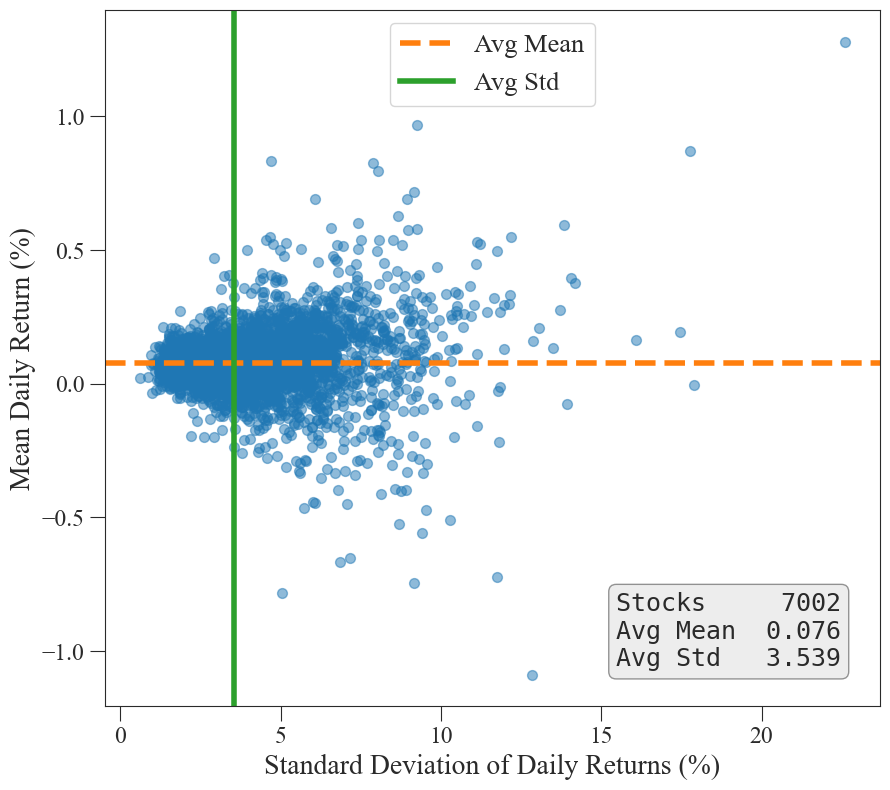

In [8]:
# DATA VISUALIZATION 2

means = ret_df.mean()
stds  = ret_df.std()

xy = np.vstack([stds, means])

fig, ax = plt.subplots()

sc = ax.scatter(stds.values, means.values, s=50, alpha=0.5, color=colors[0])

ax.axhline(means.mean(), label="Avg Mean", color=colors[2], linestyle="--")
ax.axvline(stds.mean(), label="Avg Std", color=colors[1], linestyle="-")

ax.set_xlabel("Standard Deviation of Daily Returns (%)")
ax.set_ylabel("Mean Daily Return (%)")

textstr = (f"Stocks     {len(means)}\n"
           f"Avg Mean  {means.mean():.3f}\n"
           f"Avg Std   {stds.mean():.3f}")
ax.text(0.95, 0.05, textstr, transform=ax.transAxes, verticalalignment="bottom", horizontalalignment="right", bbox=boxprops, fontfamily="monospace", fontsize=18)

ax.legend()
plt.tight_layout()
plt.savefig("./PLOTS/data_visualization2.pdf")
plt.show()


# Skew Surfaces

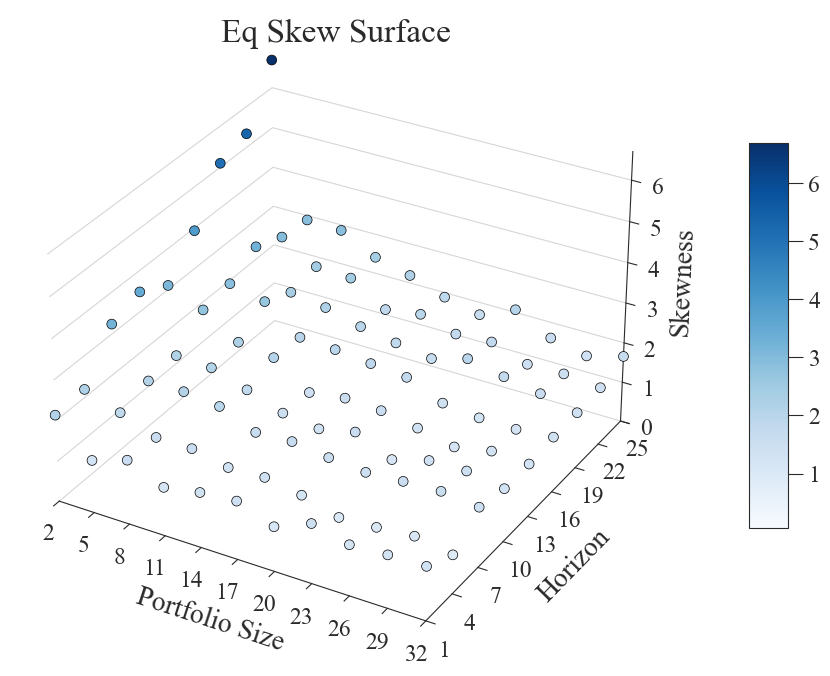

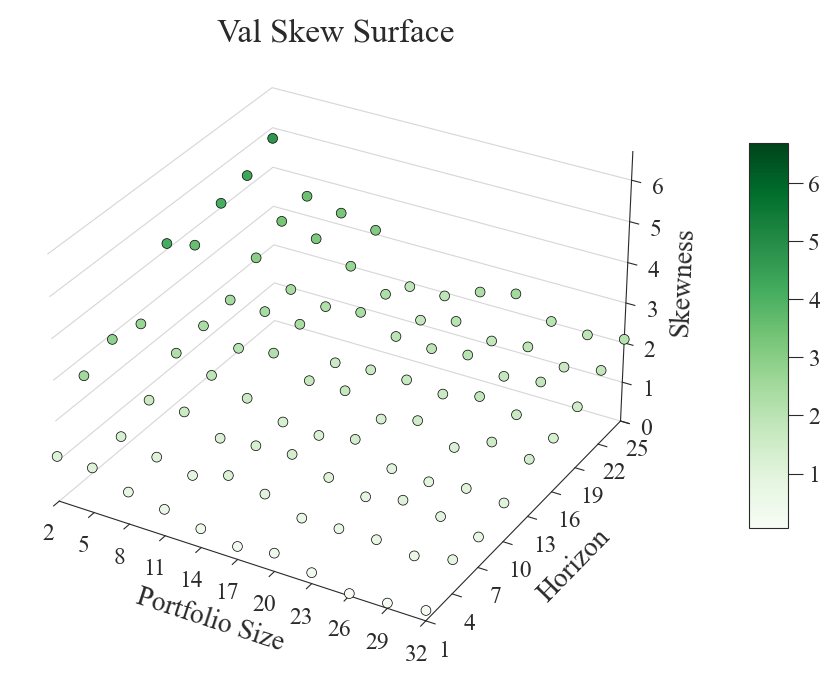

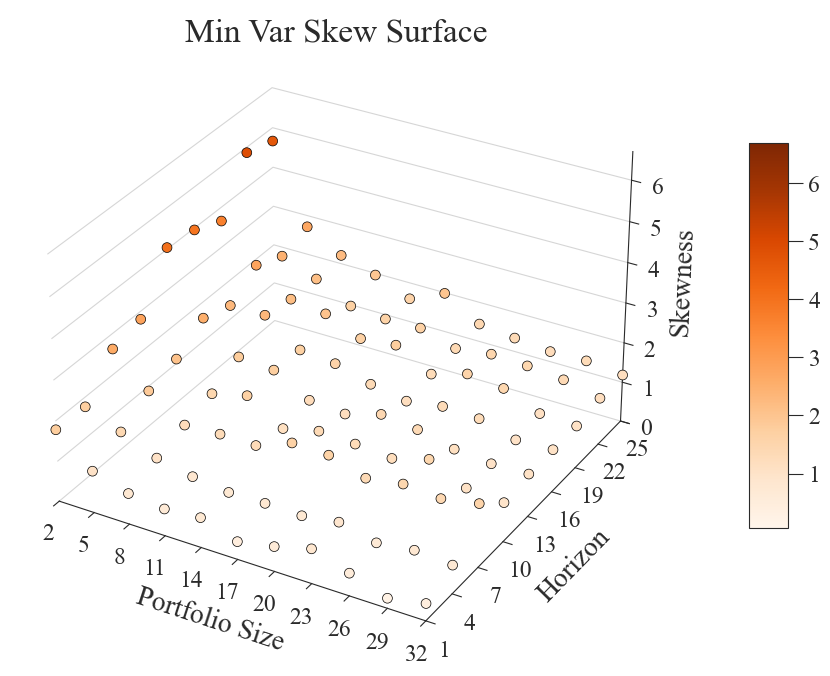

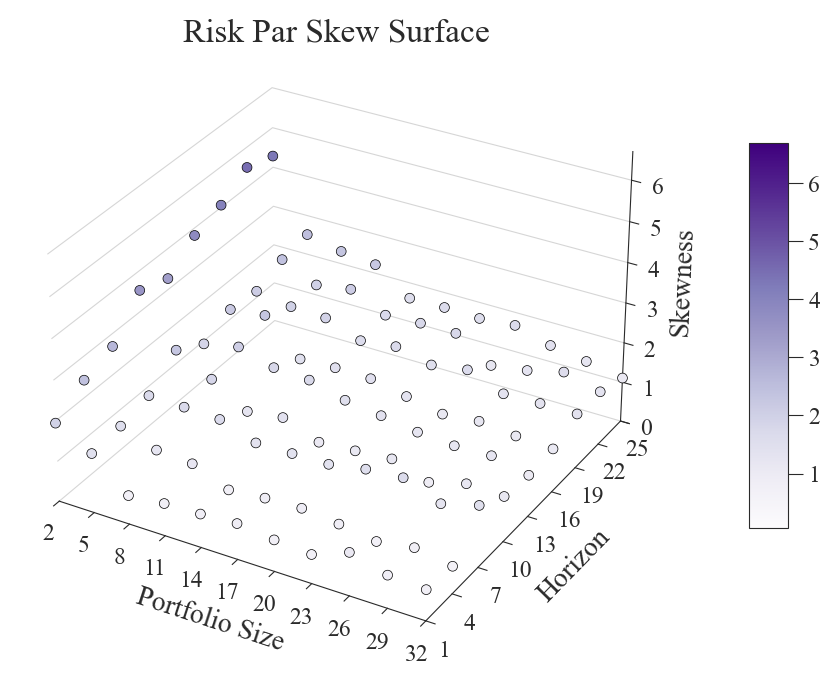

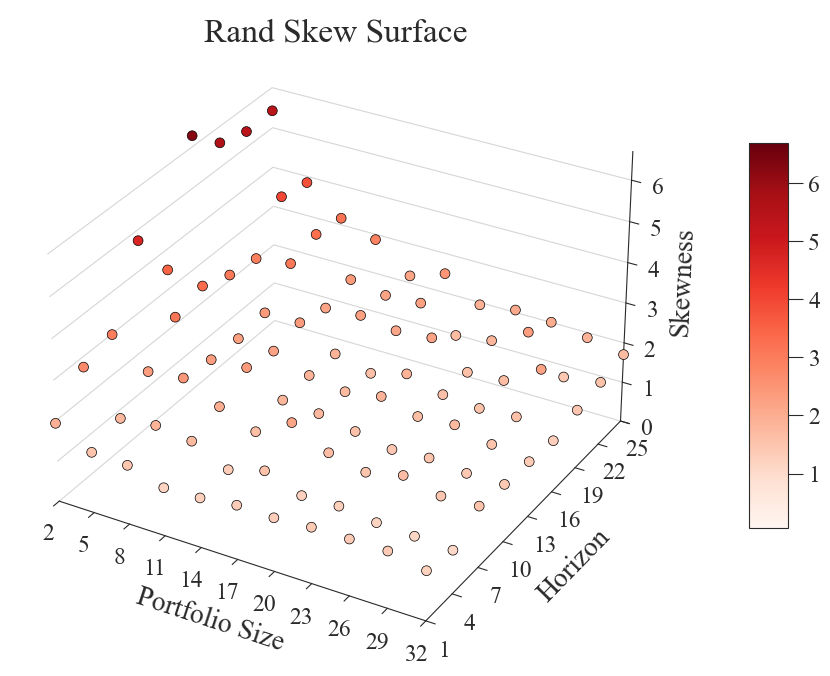

In [9]:

reg_data = pd.read_csv("./REG_DATA/reg_data_sector0_2000.csv", header=0, index_col=0)

methods = ["equal", "value", "minvar", "riskpar", "rand"]
methods_title_spelling = ["Eq", "Val", "Min Var", "Risk Par", "Rand"]

z = reg_data['longrun_skews'].values
z_max = z.max()
norm = Normalize(vmin=z.min(), vmax=z.max())

for i, method in enumerate(methods):

    filtered = reg_data[reg_data[method] == 1.0]
    x, y, z = filtered['sizes'].values, filtered['horizons'].values, filtered['longrun_skews'].values

    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    scatter = ax.scatter(x, y, z, c=z, cmap=cmaps[i], edgecolors='black', lw=0.5, s=50, alpha=1, norm=norm)

    cbar = fig.colorbar(scatter, ax=ax, shrink=0.5, aspect=10, pad=0.1)

    ax.set_zlim(0, z_max)
    ax.set_xlim(pf_sizes.min(), pf_sizes.max())
    ax.set_ylim(pf_horizons.min(), pf_horizons.max())
    ax.set_xlabel('Portfolio Size', labelpad=10)
    ax.set_ylabel('Horizon', labelpad=10)
    ax.set_zlabel('Skewness')
    ax.set_xticks(pf_sizes)
    ax.set_yticks(pf_horizons)
    ax.set_title(f"{methods_title_spelling[i]} Skew Surface", y=1.02)
    
    ax.tick_params(axis='both', direction='in')

    ax.xaxis._axinfo['grid']['color'] = (1, 1, 1, 0) # transparent white
    ax.yaxis._axinfo['grid']['color'] = (1, 1, 1, 0) 

    ax.zaxis._axinfo['grid'].update({
        'color': gridcolor,
        'linestyle': '-',
    })

    for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
        axis.pane.fill = False
        axis.pane.set_edgecolor('None')
        axis._axinfo['tick']['inward_factor'] = 0.3
        axis._axinfo['tick']['outward_factor'] = 0.0


    plt.tight_layout()
    fig.savefig(f"./PLOTS/skew-surface_{method}.pdf")
    plt.show()
    plt.close(fig)


# Regression Lines

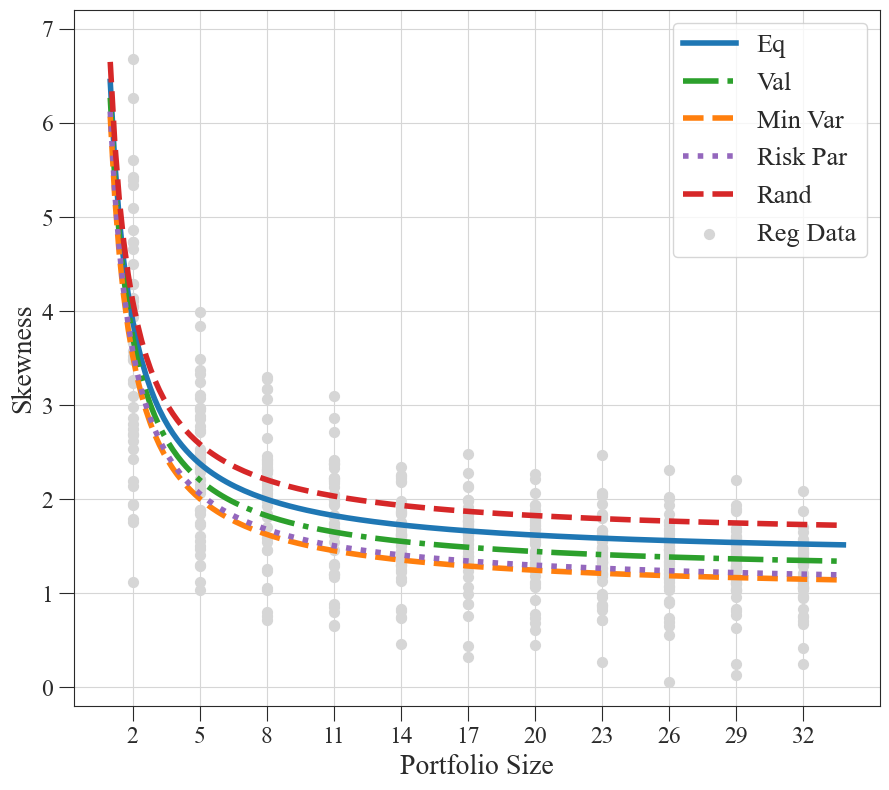

In [10]:
# SKEW

data = pd.read_csv("./REG_DATA/reg_data_sector0_2000.csv", header=0, index_col=0) 

reg_results = pd.read_csv("./REG_RESULTS/results_sector0_skew.csv", header=0, index_col=0)

coef = reg_results["Coefficient"]

# regression coefficients
intercept = coef["constant"]
beta_inv_s =  coef["1/sizes_centered"] 

method_coeffs = {
    "Val":   {"dummy": coef.loc["value"]},
    "Min Var":  {"dummy": coef.loc["minvar"]},
    "Risk Par": {"dummy": coef.loc["riskpar"]},
    "Rand":    {"dummy":  coef.loc["rand"]},
}

sizes = np.arange(pf_sizes.min() - 1, pf_sizes.max() + 2, 0.2)
inv_sizes = 1/ sizes
inv_sizes_centered = inv_sizes - inv_sizes.mean()

fig, ax = plt.subplots()

linestyles = ["-", "-.", "--", ":", "--"]

# base category
y_base = intercept + beta_inv_s * inv_sizes_centered
ax.plot(sizes, y_base, label="Eq", color=colors[0], linestyle=linestyles[0])

# for each method
for i, (method, c) in enumerate(method_coeffs.items(), start=1):
    y = (intercept + c["dummy"]) + beta_inv_s * inv_sizes_centered
    ax.plot(sizes, y, label=method, color=colors[i], linestyle=linestyles[i])

ax.grid(visible=True, color=gridcolor)

scatter_skews = data['longrun_skews']
scatter_sizes = data['sizes']
ax.scatter(scatter_sizes, scatter_skews, s=50, alpha=1, color=gridcolor, label="Reg Data")

ax.set_xlabel("Portfolio Size")

ax.set_ylabel("Skewness")

ax.set_xticks(pf_sizes)
ax.set_ylim(-0.2, 7.2)
ax.legend()
plt.tight_layout()
plt.show()
fig.savefig(f"./PLOTS/skew_reg_plot.pdf")

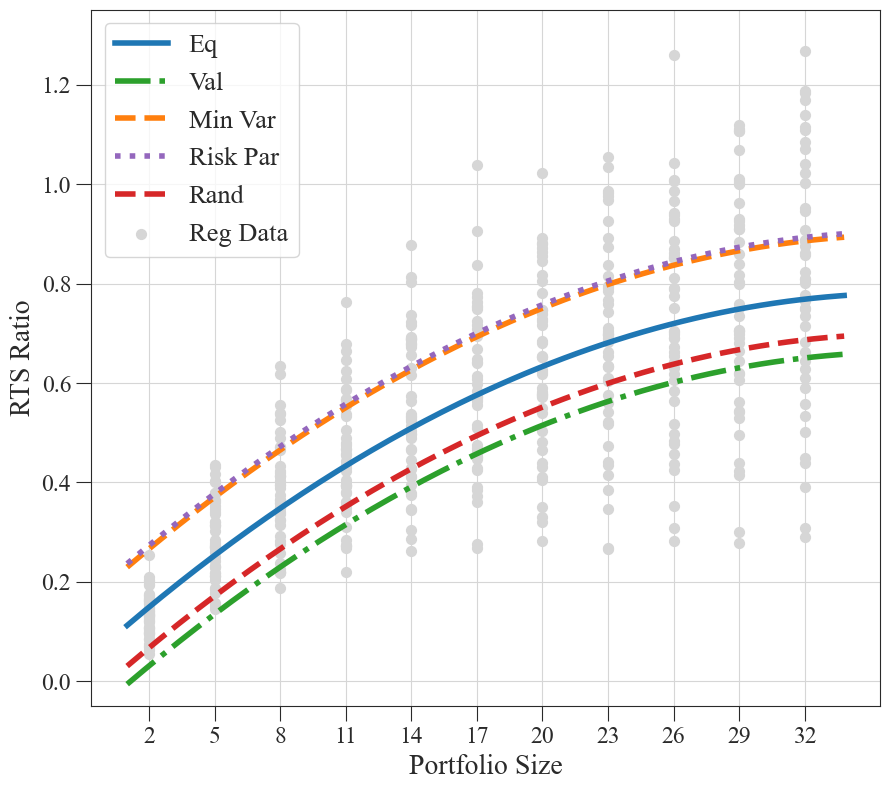

In [11]:

reg_results = pd.read_csv("./REG_RESULTS/results_sector0_ratio.csv", header=0, index_col=0)

coef = reg_results["Coefficient"]

# regression coefficients
intercept = coef["constant"]
beta_s =  coef["sizes_centered"] 
beta_s2 =  coef["sizes2_centered"] 

method_coeffs = {
    "Val":   {"dummy": coef.loc["value"]},
    "Min Var":  {"dummy": coef.loc["minvar"]},
    "Risk Par": {"dummy": coef.loc["riskpar"]},
    "Rand":    {"dummy":  coef.loc["rand"]},
}

sizes = np.arange(pf_sizes.min() - 1, pf_sizes.max() + 2, 0.2)
sizes2 = sizes ** 2
sizes_centered = sizes - sizes.mean()
sizes2_centered = sizes2 - sizes2.mean()


fig, ax = plt.subplots()

linestyles = ["-", "-.", "--", ":", "--"]

# base category
y_base = intercept + beta_s * sizes_centered + beta_s2 * sizes2_centered
ax.plot(sizes, y_base, label="Eq", color=colors[0], linestyle=linestyles[0])

# for each method
for i, (method, c) in enumerate(method_coeffs.items(), start=1):
    y = (intercept + c["dummy"]) + beta_s * sizes_centered + beta_s2 * sizes2_centered
    ax.plot(sizes, y, label=method, color=colors[i], linestyle=linestyles[i])

ax.grid(visible=True, color=gridcolor)

def ReLU(series):
    return np.maximum(0, series)

# define the ratio
def ratio(mean, std, skew):
    return mean / (std * (1 + ReLU(skew)))


scatter_ratio = ratio(mean=data['longrun_means'], std=data['longrun_stds'], skew=data['longrun_skews'])
scatter_sizes = data['sizes']
ax.scatter(scatter_sizes, scatter_ratio, s=50, alpha=1, color=gridcolor,  label="Reg Data")

ax.set_xlabel("Portfolio Size")

ax.set_ylabel("RTS Ratio")

ax.set_xticks(pf_sizes)
ax.set_ylim(-0.05, 1.35)
ax.legend()
plt.tight_layout()
plt.show()
fig.savefig(f"./PLOTS/ratio_reg_plot.pdf")

# Long-run Outcome Distributions

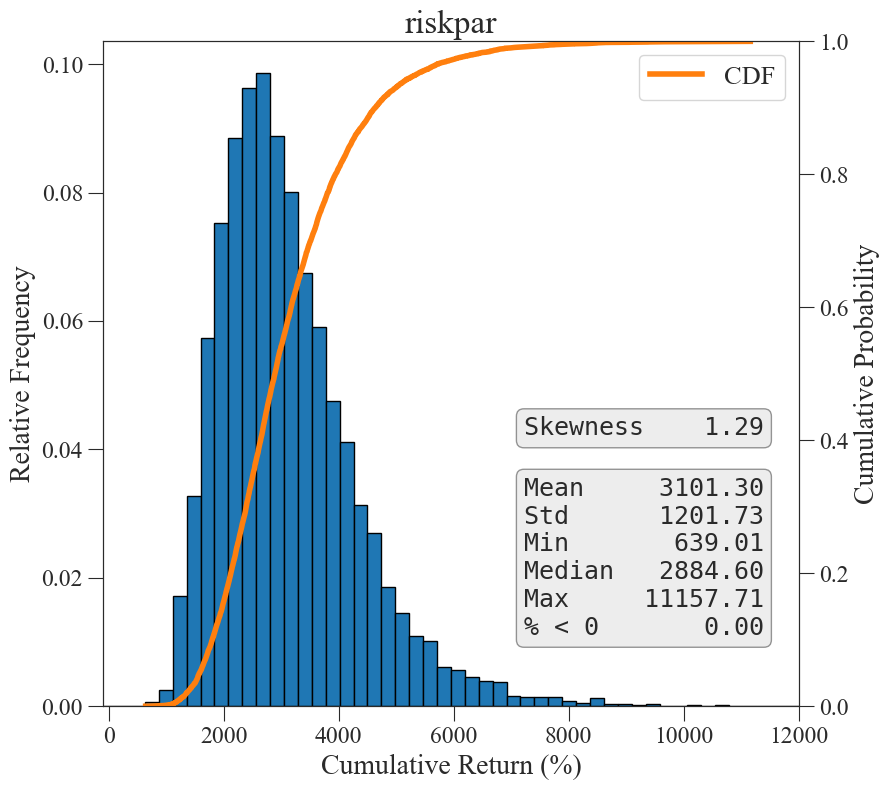

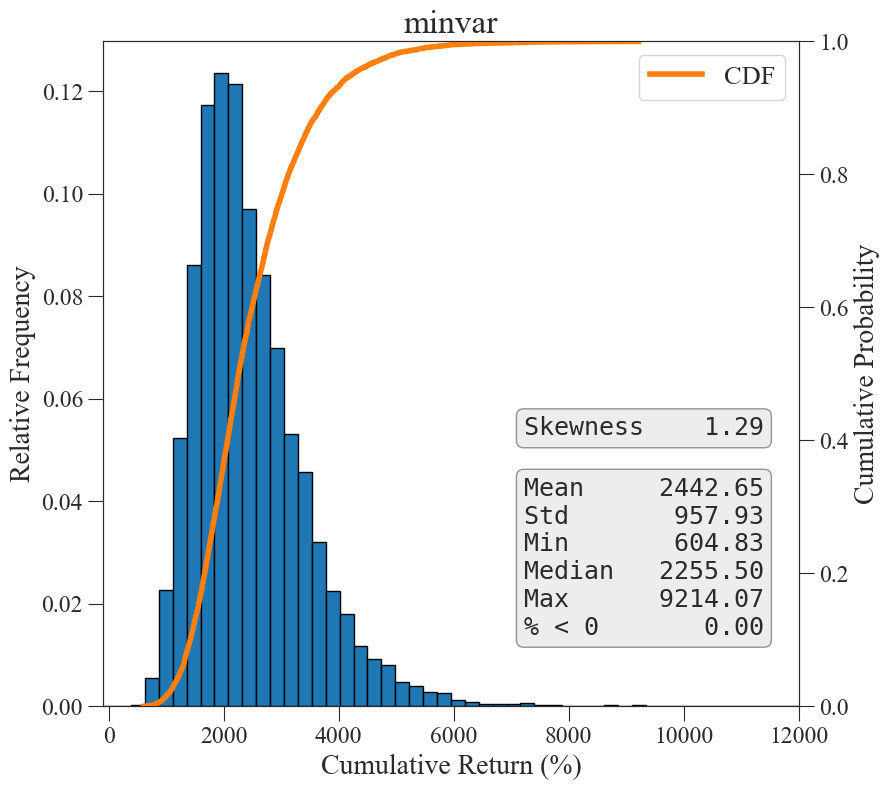

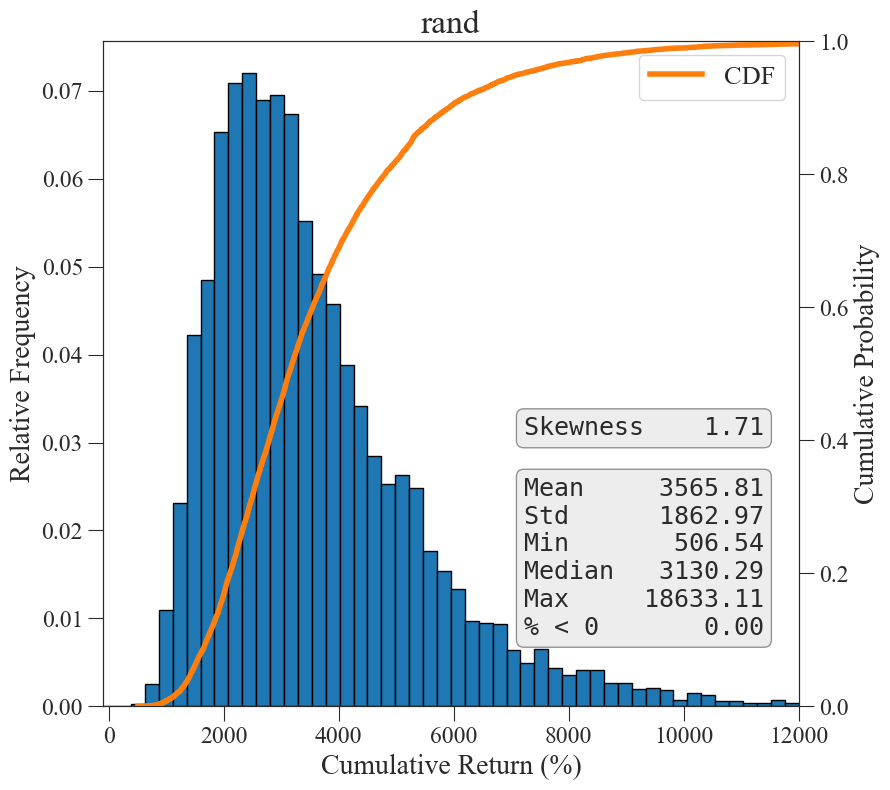

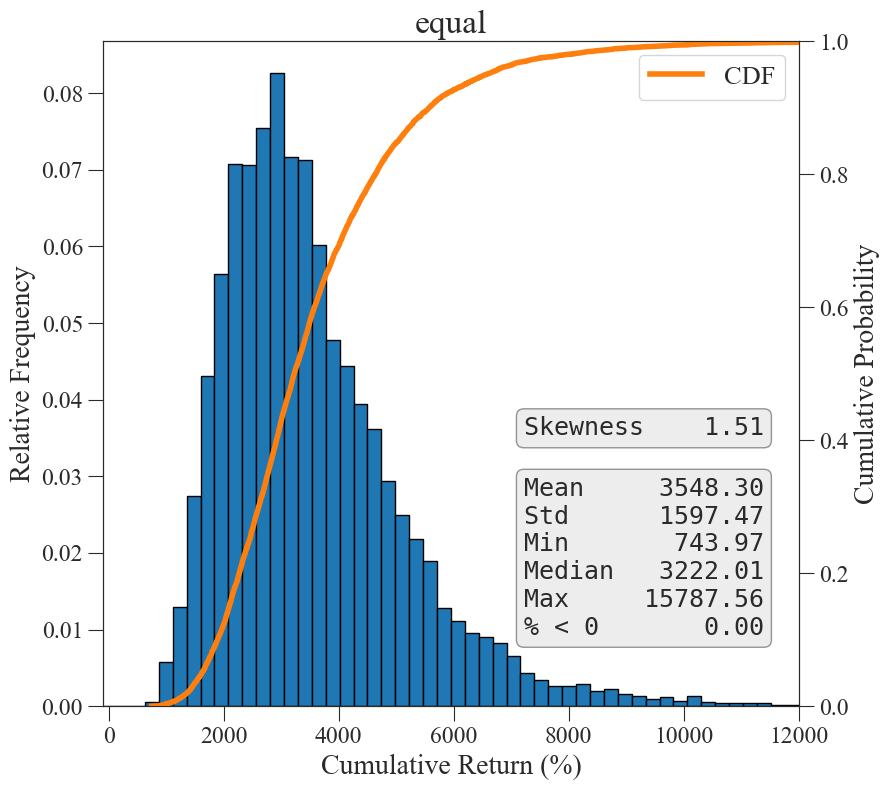

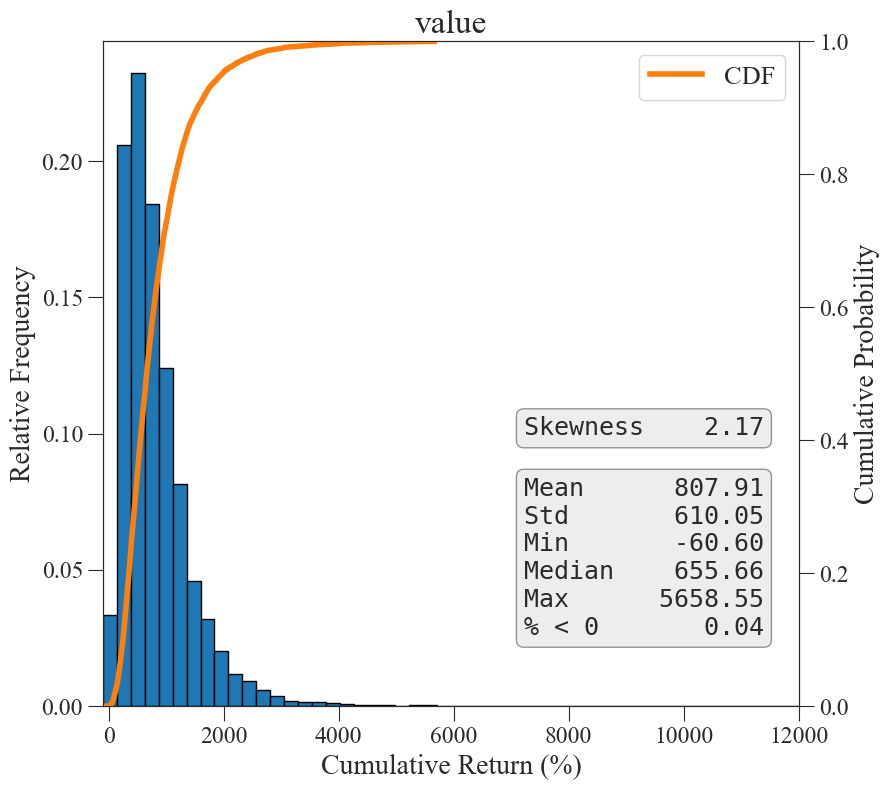

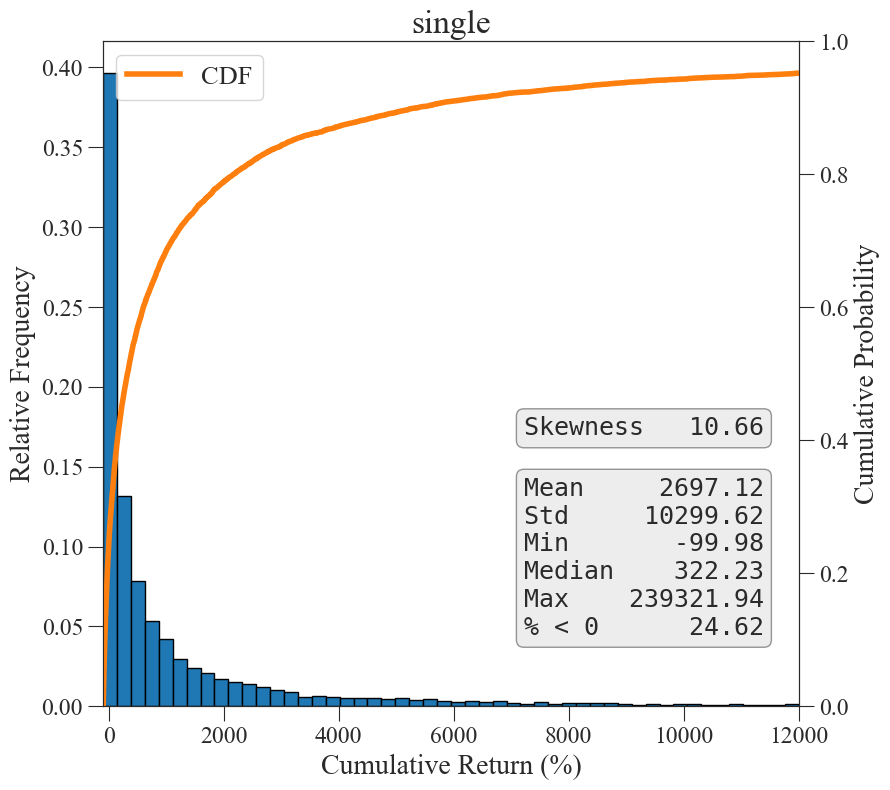

In [ ]:
n_outcomes=10000
horizon=25*12

# limits for x-axis
# remember that these are in percent
xlow = -100
xhigh = 12000
bins = np.linspace(xlow, xhigh, 50 + 1)  # +1 because linspace gives edges, not bin count

methods = ["riskpar", "minvar", "rand", "equal", "value", "single"]

for i, method in enumerate(methods):
    B = cc.BootstrapClass(return_data_path=f'./DATA/ret_full.csv', size_data_path=f'./DATA/sz_full.csv', sector="all", n_outcomes=n_outcomes)

    if method == "single":
        s = 1
    else:
        s = 32

    skew, mean, std, cum_returns = B.bootstrap_parallel(method=method, n=s, horizon=horizon)

    pct_below_zero = (cum_returns < 0).sum() / n_outcomes * 100

    fig, ax = plt.subplots()

    ax.hist(cum_returns, bins=bins, color=colors[0], edgecolor='black', weights=np.ones(len(cum_returns)) / len(cum_returns))

    # create secondary y-axis for CDF
    ax2 = ax.twinx()

    # calculate and plot CDF
    sorted_returns = np.sort(cum_returns)
    cdf = np.arange(1, len(sorted_returns) + 1) / len(sorted_returns)
    ax2.plot(sorted_returns, cdf, label='CDF', color=colors[2])
    ax2.set_ylabel('Cumulative Probability')
    ax2.tick_params(axis='y')
    ax2.set_ylim(0, 1)

    # create text box with skew
    labels = ['Skewness']
    values = [stats.skew(cum_returns)]
    stats_text = '\n'.join([f'{label:<8}{value:>8.2f}' for label, value in zip(labels, values)])
    ax.text(0.95, 0.40, stats_text, transform=ax.transAxes, verticalalignment='bottom', horizontalalignment='right', bbox=boxprops, fontfamily="monospace", fontsize=18)

    # create text box with statistics
    labels = ['Mean', 'Std', 'Min', 'Median', 'Max', '% < 0']
    values = [mean, 
        std, 
        cum_returns.min(), 
        np.median(cum_returns), 
        cum_returns.max(), 
        pct_below_zero
    ]

    stats_text = '\n'.join([f'{label:<7}{value:>9.2f}' for label, value in zip(labels, values)])
    ax.text(0.95, 0.1, stats_text, transform=ax.transAxes, verticalalignment='bottom', horizontalalignment='right', bbox=boxprops, fontfamily="monospace", fontsize=18)

    ax.set_xlim(xlow, xhigh)
    ax.set_xlabel('Cumulative Return (%)')
    ax.set_ylabel('Relative Frequency')
    ax.set_title(method)
    ax.tick_params(axis='y')

    ax2.legend()

    plt.tight_layout()
    plt.show()
    fig.savefig(f"./PLOTS/return_distribution_{method}.pdf")

